In [81]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar

## Integral de Gondolo–Silk para rho'(r)

In [82]:
G = 4.30091e-3       # pc (km/s)^2 / Msun
clight = 299792.458  # km/s

In [83]:
def schwarzschild_radius(M, G=G, clight=clight):
    return 2.0 * G * M / clight**2


def energy_lower_bound(r, M, G=G, clight=clight):
    return -G * M / r * (1.0 - 4.0 * schwarzschild_radius(M, G=G, clight=clight) / r)


def angular_momentum_capture(M, G=G, clight=clight):
    return 2.0 * clight * schwarzschild_radius(M, G=G, clight=clight)


def angular_momentum_max(Ep, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * r**2 * (Ep + G * M / r), 0.0))


def radial_velocity(Ep, Lp, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * (Ep + G * M / r - Lp**2 / (2.0 * r**2)), 0.0))

$$
v_r =
\left[
2\left(
E' + \frac{GM}{r} - \frac{{L'}^2}{2r^2}
\right)
\right]^{1/2}
\qquad
\left[
v_r
\right]
= \mathrm{km}\,\mathrm{s}^{-1},
\tag{2}
$$

$$
E'_m =
-\frac{GM}{r}
\left(
1 - \frac{4R_S}{r}
\right)
\qquad
\left[
E'_m
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2,
\tag{3}
$$

$$
L'_c = 2cR_S
\qquad
\left[
L'_c
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1},
\tag{4}
$$

$$
L'_m =
\left[
2r^2
\left(
E' + \frac{GM}{r}
\right)
\right]^{1/2}
\qquad
\left[
L'_m
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
\tag{5}
$$


In [84]:
def rho_prime_at_r(f_prime,r,M,G=G,clight=clight,epsabs=0.0,epsrel=1e-6,limit=100):
    if r <= 0.0:
        raise ValueError("r must be positive.")

    R_S = schwarzschild_radius(M, G=G, clight=clight)
    if r <= 4.0 * R_S:
        return 0.0

    E_m = energy_lower_bound(r, M, G=G, clight=clight)
    L_c = angular_momentum_capture(M, G=G, clight=clight)
    L_c2 = L_c**2

    def inner(Ep):
        L_m = angular_momentum_max(Ep, r, M, G=G)
        L_m2 = L_m**2
        if L_m2 <= L_c2:
            return 0.0

        u_max = np.sqrt(L_m2 - L_c2)

        def u_integrand(u):
            return f_prime(Ep, np.sqrt(np.maximum(L_m2 - u**2, 0.0)))

        value, _ = quad(u_integrand,0.0,u_max,epsabs=epsabs,epsrel=epsrel,limit=limit)
        return 4.0 * np.pi / r * value

    rho, _ = quad(inner,E_m,0.0,epsabs=epsabs,epsrel=epsrel,limit=limit)
    return rho

$$
\rho'(r) =
\int_{E'_m}^{0} dE'
\int_{L'_c}^{L'_m} dL'\,
\frac{4\pi L'}{r^2 v_r}\,
f'(E', L')
\qquad
\left[
\rho'
\right]
= M_\odot\,\mathrm{pc}^{-3}
\tag{1}
$$


In [85]:
def rho_prime_profile(f_prime, r_array, M, **kwargs):
    return np.array([rho_prime_at_r(f_prime, r, M, **kwargs) for r in r_array])

In [86]:
M = 2.6e6        # Msun
rho0 = 1.0       # Msun / pc^3
sigma_v = 100.0  # km/s

f0 = rho0 * (2*np.pi*sigma_v**2)**(-1.5)

def f_prime_const(Ep, Lp):
    return f0


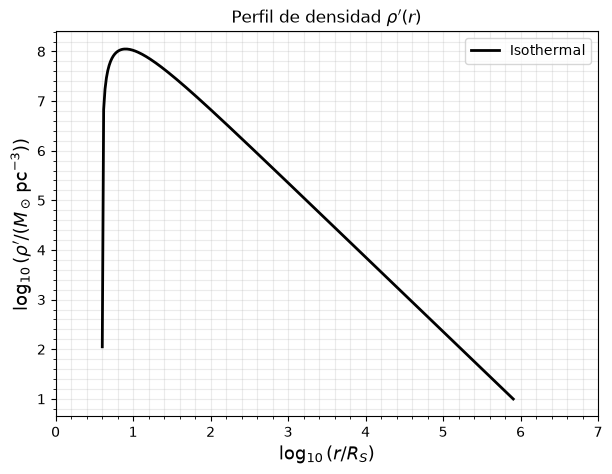

In [87]:
R_S = schwarzschild_radius(M)

r_values = np.logspace(np.log10(4.0001 * R_S),np.log10(0.2),300)
rho_values = rho_prime_profile(f_prime_const, r_values, M)
x_values = np.log10(r_values / R_S)
y_values = np.log10(rho_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values,y_values,color="black",lw=2,label="Isothermal")
plt.xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
plt.ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$", fontsize=13)
plt.title(r"Perfil de densidad $\rho'(r)$")
plt.xlim(0, 7)
plt.grid(True, which="both", alpha=0.25)
plt.minorticks_on()
plt.legend(frameon=True)

plt.show()


## Evolución adiabática

Construimos la DF final mediante el mapeo adiabático:

$$
f'(E',L') = f(E,L),
\qquad
L = L',
\qquad
I_i(E,L) = I_f(E',L').
$$

Aquí \(E'\) (`Ep`) es la energía específica final en el potencial kepleriano del agujero negro, con unidades \((\mathrm{km}/\mathrm{s})^2\), y para órbitas ligadas \(E' < 0\). La variable inicial \(E\) de las ecuaciones de Gondolo-Silk es positiva y no debe confundirse con `Ep`. El momento angular específico \(L'\) (`Lp`) se mide en \(\mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}\).


In [ ]:
from scipy.special import gammaln
from scipy.special import beta as beta_function

<!-- GS_FORMULAS_WITH_UNITS -->
### Perfil inicial cuspidado y parámetros de Gondolo–Silk

$$
\rho_i(r) =
\rho_0
\left(
\frac{r}{r_0}
\right)^{-\gamma}
\qquad
\left[
\rho_i
\right]
= M_\odot\,\mathrm{pc}^{-3}
$$

$$
\phi_0 =
\frac{4\pi G r_0^2 \rho_0}{(3-\gamma)(2-\gamma)}
\qquad
\left[
\phi_0
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2
$$

$$
\beta =
\frac{6-\gamma}{2(2-\gamma)}
\qquad
\left[
\beta
\right]
= 1
$$

$$
p =
\frac{4-\gamma}{2(2-\gamma)}
\qquad
\left[
p
\right]
= 1
$$

$$
\lambda =
\left(
\frac{2}{4-\gamma}
\right)^{1/(2-\gamma)}
\left(
\frac{2-\gamma}{4-\gamma}
\right)^{1/2}
\qquad
\left[
\lambda
\right]
= 1
$$

$$
b =
\frac{\pi(2-\gamma)}{B\left((2-\gamma)^{-1},\,3/2\right)}
\qquad
\left[
b
\right]
= 1
$$


In [ ]:
def gs_phi0(gamma, rho0, r0, G=G):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if rho0 <= 0.0:
        raise ValueError("rho0 must be positive.")
    if r0 <= 0.0:
        raise ValueError("r0 must be positive.")

    return 4.0 * np.pi * G * r0**2 * rho0 / ((3.0 - gamma) * (2.0 - gamma))


def gs_beta_exponent(gamma):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (6.0 - gamma) / (2.0 * (2.0 - gamma))


def gs_action_exponent(gamma):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (4.0 - gamma) / (2.0 * (2.0 - gamma))


def gs_lambda(gamma):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return (
        (2.0 / (4.0 - gamma))**(1.0 / (2.0 - gamma))
        * ((2.0 - gamma) / (4.0 - gamma))**0.5
    )


def gs_b(gamma):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    return np.pi * (2.0 - gamma) / beta_function(1.0 / (2.0 - gamma), 1.5)


<!-- GS_FORMULAS_WITH_UNITS -->
### Ecuación (7): función de distribución inicial

$$
f(E,L) =
\frac{\rho_0}{(2\pi\phi_0)^{3/2}}
\frac{\Gamma(\beta)}{\Gamma(\beta-3/2)}
\left(
\frac{\phi_0}{E}
\right)^\beta
\qquad
\left[
f
\right]
= M_\odot\,\mathrm{pc}^{-3}
(\mathrm{km}\,\mathrm{s}^{-1})^{-3}
$$

Aquí \(E>0\) es la energía inicial positiva de Gondolo–Silk, no la energía final \(E'\).


In [ ]:
def f_initial_gs_eq7(E, L, gamma, rho0, r0, G=G):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if E <= 0.0:
        raise ValueError("Initial GS energy E must be positive.")
    if rho0 <= 0.0:
        raise ValueError("rho0 must be positive.")
    if r0 <= 0.0:
        raise ValueError("r0 must be positive.")

    phi0 = gs_phi0(gamma, rho0, r0, G=G)
    beta = gs_beta_exponent(gamma)

    if phi0 <= 0.0:
        raise ValueError("phi0 must be positive.")
    if beta <= 1.5:
        raise ValueError("The GS Eq. (7) beta exponent must be larger than 1.5.")

    log_f = (
        np.log(rho0)
        - 1.5 * np.log(2.0 * np.pi * phi0)
        + gammaln(beta)
        - gammaln(beta - 1.5)
        + beta * (np.log(phi0) - np.log(E))
    )
    return np.exp(log_f)


<!-- GS_FORMULAS_WITH_UNITS -->
### Ecuación (8): acción radial inicial

$$
I_i(E,L) =
\frac{2\pi}{b}
\left[
-\frac{L}{\lambda}
+ \sqrt{2r_0^2\phi_0}
\left(
\frac{E}{\phi_0}
\right)^p
\right]
\qquad
\left[
I_i
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}
$$

$$
\left[
E
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2,
\qquad
\left[
L
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}
$$


In [ ]:
def radial_action_initial_gs_eq8(E, L, gamma, rho0, r0, G=G):
    if not (0.0 < gamma < 2.0):
        raise ValueError("gamma must satisfy 0 < gamma < 2.")
    if E <= 0.0:
        raise ValueError("Initial GS energy E must be positive.")
    if L < 0.0:
        raise ValueError("L must be non-negative.")
    if rho0 <= 0.0:
        raise ValueError("rho0 must be positive.")
    if r0 <= 0.0:
        raise ValueError("r0 must be positive.")

    phi0 = gs_phi0(gamma, rho0, r0, G=G)
    p = gs_action_exponent(gamma)
    lam = gs_lambda(gamma)
    b = gs_b(gamma)

    if phi0 <= 0.0:
        raise ValueError("phi0 must be positive.")
    if b <= 0.0:
        raise ValueError("b must be positive.")
    if lam <= 0.0:
        raise ValueError("lambda must be positive.")

    return (2.0 * np.pi / b) * (
        -L / lam + np.sqrt(2.0 * r0**2 * phi0) * (E / phi0)**p
    )


<!-- GS_FORMULAS_WITH_UNITS -->
### Inversa analítica de la acción inicial

Si \(I_\mathrm{target} = I_f(E',L')\), \(L=L'\), y

$$
A = \sqrt{2r_0^2\phi_0}
\qquad
\left[
A
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1},
$$

entonces

$$
X =
\frac{(b/2\pi)I_\mathrm{target} + L/\lambda}{A}
\qquad
\left[
X
\right]
= 1
$$

y

$$
E =
\phi_0 X^{1/p}
\qquad
\left[
E
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2.
$$


In [ ]:
def initial_energy_from_action_gs_eq8(I_target, L, gamma, rho0, r0, G=G):
    if not np.isfinite(I_target):
        raise ValueError("I_target must be finite.")
    if L < 0.0:
        raise ValueError("L must be non-negative.")

    phi0 = gs_phi0(gamma, rho0, r0, G=G)
    p = gs_action_exponent(gamma)
    lam = gs_lambda(gamma)
    b = gs_b(gamma)
    A = np.sqrt(2.0 * r0**2 * phi0)

    X = ((b / (2.0 * np.pi)) * I_target + L / lam) / A
    if X <= 0.0 or not np.isfinite(X):
        raise ValueError(f"Invalid GS Eq. (8) inverse argument: X={X}.")

    E = phi0 * X**(1.0 / p)
    if E <= 0.0 or not np.isfinite(E):
        raise ValueError(f"Invalid initial energy from GS Eq. (8): E={E}.")

    return E


<!-- GS_FORMULAS_WITH_UNITS -->
### Acción radial final en el potencial kepleriano

El potencial final del agujero negro es

$$
\Phi_f(r) = -\frac{GM}{r}
\qquad
\left[
\Phi_f
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2.
$$

La velocidad radial final es

$$
v_r =
\left[
2\left(
E' + \frac{GM}{r} - \frac{{L'}^2}{2r^2}
\right)
\right]^{1/2}
\qquad
\left[
v_r
\right]
= \mathrm{km}\,\mathrm{s}^{-1}.
$$

Para órbitas keplerianas ligadas:

$$
a = -\frac{GM}{2E'}
\qquad
\left[
a
\right]
= \mathrm{pc},
$$

$$
e^2 =
1 + \frac{2E'{L'}^2}{(GM)^2}
\qquad
\left[
e
\right]
= 1,
$$

$$
r_\mathrm{peri} = a(1-e),
\qquad
r_\mathrm{apo} = a(1+e),
\qquad
\left[
r_\mathrm{peri}, r_\mathrm{apo}
\right]
= \mathrm{pc}.
$$

La acción radial final se calcula como

$$
I_f(E',L') =
2\int_{r_\mathrm{peri}}^{r_\mathrm{apo}}
v_r(E',L',r)\,dr
\qquad
\left[
I_f
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
$$


In [ ]:
def kepler_turning_points(Ep, Lp, M, G=G, tol=1e-12):
    if Ep >= 0.0:
        raise ValueError("Ep must be negative for a bound keplerian orbit.")
    if Lp < 0.0:
        raise ValueError("Lp must be non-negative.")
    if M <= 0.0:
        raise ValueError("M must be positive.")

    mu = G * M
    a = -mu / (2.0 * Ep)
    e2 = 1.0 + 2.0 * Ep * Lp**2 / mu**2

    if e2 < 0.0:
        if e2 >= -tol:
            e2 = 0.0
        else:
            raise ValueError(f"Computed e^2 is negative beyond tolerance: e2={e2}.")

    if e2 > 1.0 + tol:
        raise ValueError(f"Computed e^2 is larger than 1 for a bound orbit: e2={e2}.")

    e2 = min(e2, 1.0)
    e = np.sqrt(e2)
    r_peri = a * (1.0 - e)
    r_apo = a * (1.0 + e)

    if r_peri <= 0.0:
        raise ValueError(f"Invalid periapsis: r_peri={r_peri}.")
    if r_apo < r_peri:
        raise ValueError(f"Invalid apoapsis: r_apo={r_apo}, r_peri={r_peri}.")

    return r_peri, r_apo


def radial_action_final_numeric(
    Ep,
    Lp,
    M,
    G=G,
    epsabs=0.0,
    epsrel=1e-8,
    limit=100,
):
    r_peri, r_apo = kepler_turning_points(Ep, Lp, M, G=G)

    if np.isclose(r_apo, r_peri, rtol=1e-12, atol=0.0):
        return 0.0

    r_mid = 0.5 * (r_apo + r_peri)
    r_half_width = 0.5 * (r_apo - r_peri)

    def theta_integrand(theta):
        r = r_mid + r_half_width * np.cos(theta)
        dr_dtheta_abs = r_half_width * np.sin(theta)
        return radial_velocity(Ep, Lp, r, M, G=G) * dr_dtheta_abs

    value, _ = quad(
        theta_integrand,
        0.0,
        np.pi,
        epsabs=epsabs,
        epsrel=epsrel,
        limit=limit,
    )
    return 2.0 * value


<!-- GS_FORMULAS_WITH_UNITS -->
### Construcción de la función de distribución final

La conservación adiabática se implementa como

$$
I_i(E,L') = I_f(E',L')
\qquad
\left[
I_i, I_f
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1},
$$

con

$$
L = L'
\qquad
\left[
L, L'
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
$$

Luego

$$
f'(E',L') =
f(E,L')
\qquad
\left[
f'
\right]
= M_\odot\,\mathrm{pc}^{-3}
(\mathrm{km}\,\mathrm{s}^{-1})^{-3}.
$$


In [ ]:
def make_f_prime_gs_cusp(
    gamma,
    rho0,
    r0,
    M,
    G=G,
    final_action_func=radial_action_final_numeric,
    return_zero_on_fail=False,
):
    gs_phi0(gamma, rho0, r0, G=G)

    def f_prime_adiabatic(Ep, Lp):
        if Ep >= 0.0:
            return 0.0

        try:
            I_target = final_action_func(Ep, Lp, M, G=G)
            E_initial = initial_energy_from_action_gs_eq8(
                I_target,
                Lp,
                gamma,
                rho0,
                r0,
                G=G,
            )
            return f_initial_gs_eq7(E_initial, Lp, gamma, rho0, r0, G=G)
        except Exception:
            if return_zero_on_fail:
                return 0.0
            raise

    return f_prime_adiabatic


### Inputs físicos para el caso cuspidado de Gondolo–Silk


In [95]:
gamma = 1.0

D_pc = 8.5e3  # pc, distancia solar al centro galáctico

# Normalización conservadora aproximada usada por Gondolo-Silk:
# rho_D/(1 - gamma/3) = 0.0062 Msun pc^-3.
rho_D = 0.0062 * (1.0 - gamma / 3.0)  # Msun pc^-3
r0 = D_pc
rho0 = rho_D

f_prime_adiabatic = make_f_prime_gs_cusp(
    gamma=gamma,
    rho0=rho0,
    r0=r0,
    M=M,
    final_action_func=radial_action_final_numeric,
    return_zero_on_fail=False,
)


## Perfil de densidad final a partir de f'(E', L')


In [ ]:
import matplotlib.pyplot as plt

if "f_prime_adiabatic" not in globals():
    raise NameError(
        "f_prime_adiabatic is not defined. Build it first using "
        "make_f_prime_gs_cusp with gamma, rho0 and r0."
    )

R_S = schwarzschild_radius(M)

r_values_adiabatic = np.logspace(
    np.log10(4.05 * R_S),
    np.log10(0.2),
    60
)

rho_values_adiabatic = rho_prime_profile(
    f_prime_adiabatic,
    r_values_adiabatic,
    M,
    epsrel=1e-5,
    limit=100,
)

x_values_adiabatic = np.log10(r_values_adiabatic / R_S)
positive_mask = rho_values_adiabatic > 0

if not np.any(positive_mask):
    raise ValueError("No positive density values were obtained.")

x_plot = x_values_adiabatic[positive_mask]
y_plot = np.log10(rho_values_adiabatic[positive_mask])


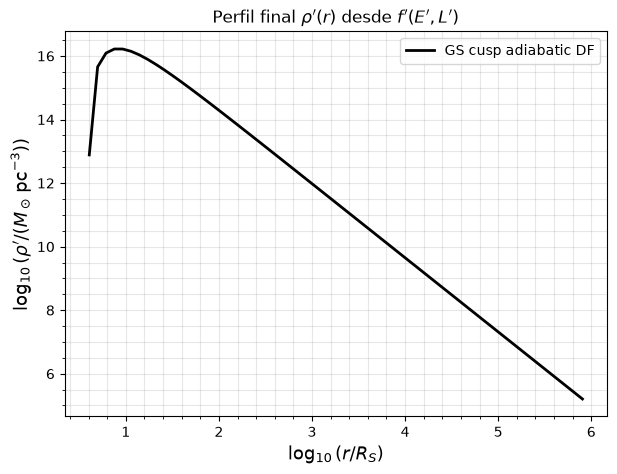

In [97]:
plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, lw=2, color="black", label="GS cusp adiabatic DF")
plt.xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
plt.ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$", fontsize=13)
plt.title(r"Perfil final $\rho'(r)$ desde $f'(E',L')$")
plt.grid(True, which="both", alpha=0.3)
plt.minorticks_on()
plt.legend()
plt.show()
